## Softmax

Podemos usar a propriedade:
$$
\sigma_i = \frac{e^{z_i}}{e^z}
$$

em que relacionamos cada uma das iterações com um peso. Note que quanto mais iterações ($i \rightarrow \infty$), menores são os valores de $\sigma_i$ para cada iteração.

In [41]:
# import libraries
import numpy as np
import torch
import torch.nn as nn # library used to neural networks
import matplotlib.pyplot as plt

In [42]:
# manually in numpy

# the list of numbers
z = [1,2,3]

# compute the softmax result
num = np.exp(z)
den = np.sum( (np.exp(z)) )
sigma = num/den

print(sigma)
print(np.sum(sigma))

[0.09003057 0.24472847 0.66524096]
1.0


[ 1 13  4 -5  2 -5 14 12 14 -2  3  4  0  7 -4  7 -1 12 12 14 -3 12  7 -1
 14]


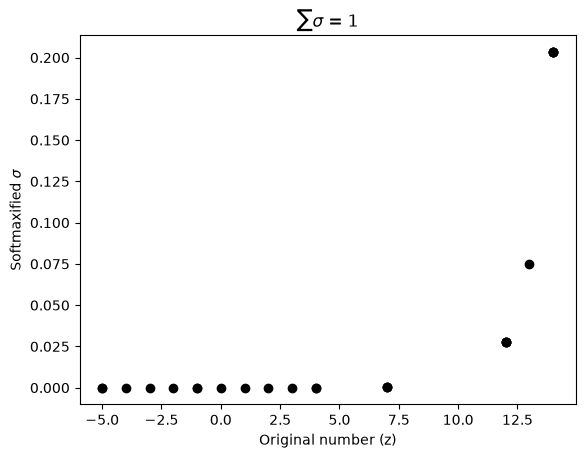

In [49]:
# repeat with some random integers
z = np.random.randint(-5,high=15,size=25)
print(z)

# compute the softmax result
num = np.exp(z)
den = np.sum( num )
sigma = num / den

# compare
plt.plot(z,sigma,'ko')
plt.xlabel('Original number (z)')
plt.ylabel(r'Softmaxified $\sigma$')
#plt.yscale('log')
plt.title(r'$\sum\sigma$ = %g' %np.sum(sigma))
plt.show()

**Using pytorch**

In [46]:
# slightly more involved using torch.nn

# create an instance of the softmax activation class
softfun = nn.Softmax(dim=0)

# then apply the data to that function
sigmaT = softfun( torch.Tensor(z) )

# now we get the result
print(sigmaT)

tensor([2.2347e-06, 4.9222e-02, 6.0744e-06, 4.4884e-05, 9.0153e-04, 1.1126e-07,
        8.2209e-07, 3.0243e-07, 6.6614e-03, 5.5392e-09, 9.0153e-04, 1.3380e-01,
        6.6614e-03, 6.6614e-03, 4.9222e-02, 3.0243e-07, 6.0744e-06, 3.3165e-04,
        4.4884e-05, 1.6512e-05, 3.6370e-01, 1.8108e-02, 6.0744e-06, 4.0929e-08,
        3.6370e-01])


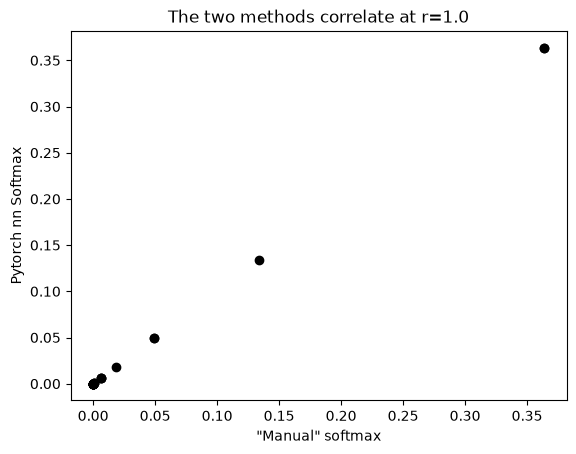

In [47]:
#show that they are the same
plt.plot(sigma,sigmaT,'ko')
plt.xlabel('"Manual" softmax')
plt.ylabel('Pytorch nn Softmax')
plt.title(f'The two methods correlate at r={np.corrcoef(sigma,sigmaT)[0,1]}')
plt.show()